# 1. Loading
The used models can be seen in the first code cell (CHECKPOINTS).<br>
Relevant training and model information can be seen in "Relevant Training Information".

In [63]:
import sys
from os import path, getcwd
import pathlib

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

# data paths
DATA_DIR = path.join(ROOT, 'data/')
# checkpoints of preprocessed data
CHECKPOINTS = {'nf': path.join(DATA_DIR, 'checkpoints/nf/RealNVP_6_mnist_cls-0/05-21_10-31-27/'),
              'survae': path.join(DATA_DIR, 'checkpoints/survae/survae_steps-12_scales-2_pool-max_mnist_cls-0/05-21_10-27-06/')}

In [64]:
%reload_ext autoreload
%autoreload 2

# Plotting Functions
from plotting import *
from precomputation.jupyter_imports import *
from misc.common_functions import load_configs

_=%matplotlib inline

### 1.1 Loading Models and Training Data

In [65]:
# config
configs, MAIN_TEST_CLS = load_configs(CHECKPOINTS, DATA_DIR, verbose=False)
# Data
all_loaders = load_data(configs, verbose=False)
# Precomputed information
all_losses, samples, artificial_images, _ = load_preprocessings(CHECKPOINTS)

--- 

# 2. Notation and Definitions


$\newcommand{\finv}{f^{-1}}$
$\newcommand{\px}{p_X(x)}$
$\newcommand{\pxbpd}{\log p_X(x) \text{ in bpd}}$
$\newcommand{\pxibpd}{\log p_X(x_i) \text{ in bpd}}$
$\newcommand{\pz}{p_Z(z)}$
$\newcommand{\fNF}{f_{\text{NF}}}$
$\newcommand{\fSVAE}{f_{\text{SVAE}}}$
$\newcommand{\finvNF}{\finv_{\text{NF}}}$
$\newcommand{\finvSVAE}{\finv_{\text{SVAE}}}$
$\newcommand{\X}{\mathfrak{X}}$
$\newcommand{\Z}{\mathcal{Z}}$
$\newcommand{\lline}{\rule{5cm}{0.4pt}}$

We begin by establishing notation and definitions. <br>
<b>Please refer to this section in case used notation is unclear.</b><br>
$\X$: Data-Space (e.g. $\X = [0, 1]^{28 \times 28} \subseteq \mathbb{R}^{28 \times 28}$ for mnist)<br>
$\Z$: Latent-Space (e.g. $\Z = \mathbb{R}^{(28 \cdot 28)}$ for MNIST and a Normalizing Flow)<br>
$x \in \X$ : $x$ is referred to as image<br> 
$z \in \Z$ : $z$ is referred to as latent code<br>
$D \subseteq \X$: real world dataset, finite<br>
$D = D_0 \cup ... \cup D_L$ : Partition on the training set, where the index denotes the class and $L$ is the last class (e.g. $D_3$ for MNIST is the set containing all images with the number "3")<br>
$D_i = D_i^t \cup D_i^e$: Partition on $D_i$. $D_i^t$ is a training set and $D_i^e$ is a test set ($e$ for evaluation). <br>
$D_c^t$: main training data set<br>
$c$: main class on which we train. <br>
$\lline$<br>

$X_c$: Random variable / random image from which the images in $D_c$ were drawn<br>
$Z$: Random variable in latent space<br>
$X_c \sim F$: $X_c$ is distributed according to an unknown probability distribution $F$. Our goal is to approximate the true probability density function (pdf) $p^*(x_c)$.<br>
$Z \sim G$: $G$ is the prior distribution of $Z$. Usually $G = N(0,1)$.<br>
$p_Z(z)$: known pdf of $G$<br>
$x, z$: a sample / realization drawn from the according distribution<br>
$\lline$<br>

$f_{\theta}: \Z \rightarrow \X$ Transformation <br>
$f^{-1}_{\theta}: \X \rightarrow \Z$ Inverse Transformation <br>
$\theta$ trainable parameters of $f$. For simplicity we drop $\theta$.<br>
$\lline$<br>

$\px = p(x) = p_z(\finv (x)) \cdot V(x, z)$ : approximation for $p^*$<br>
$V(x, z)$: likelihood contribution (see: [1, Section 2])<br>
$\log p(x)$ in bpd = $\frac{\log \px}{dim(x) \cdot \log(2)} = \frac{\log_2 \px}{dim(x)}$: log likelihood in bits per dimension<br>
$\lline$<br>

$\max_{\theta} \sum_{x \in D_c^{t}} \log \px$: the optimization term during training <br>
This means, for an optimal $f$, $f(Z) = X \sim F$<br>
$\lline$<br>

We trained two models.
A Normalizing Flow (NF) (the RealNVP Flow from [2]) and a Surjective Variational Autoencoder (SurVAE) (the MaxPoolFlow from [2, I.3]). 
We sometimes refer to them as $\finvNF$ and $\fNF$ or $\finvSVAE$ and $\fSVAE$ respectively.<br>
Above each plot, we denote which model was used to compute the seen values.<br>
Note that we evaluate the checkpoint that performed best on the test set $D_c^e$ during training.

$\lline$<br>
<u>Legend Denomination</u><br>
"$c$ (test)" refers to the test subset $D_c^{e}$ <br>
"$c$ (train)" refers to the test subset $D_c^{t}$ <br>
"$j$" where $j \neq c$ refers to all other the classes which are not used for training. The datasets used for evaluation of the other classes the training sets $D_j^t$, as it is bigger and not used during training.<br>
"Mean" of $j$ refers to the average log likelihood in bpd: $\frac{1}{|D_j^h|} \sum_{x \in D_j^h} \pxbpd$, where $h \in \{t, e\}$<br>
$\lline$<br>
We did not use Latex within the plots as it made plotting slow and more unclear.<br>

References:<br>
[1] Nielsen, Didrik, et al. " SurVAE Flows: Surjections to Bridge the Gap between VAEs and Flows." Advances in Neural Information Processing Systems 33 (2020).

[2] Kirichenko, Polina, Pavel Izmailov, and Andrew Gordon Wilson. "Why normalizing flows fail to detect out-of-distribution data." arXiv preprint arXiv:2006.08545 (2020).

# 3. KDE plots of the log likelihoods in bpd
We first plot the histogram of $\{\pxbpd | x \in D_j\}$ with a kernel density estimation, where $j$ can be seen in the legend.<br>
Note that the x axes are aligned.<br>
We see how both models assign much higher likelihoods to class '1'. We have repeated this experiment with training class '8' and '1' and find the same result: class '1' gets highest likelihood.<br>

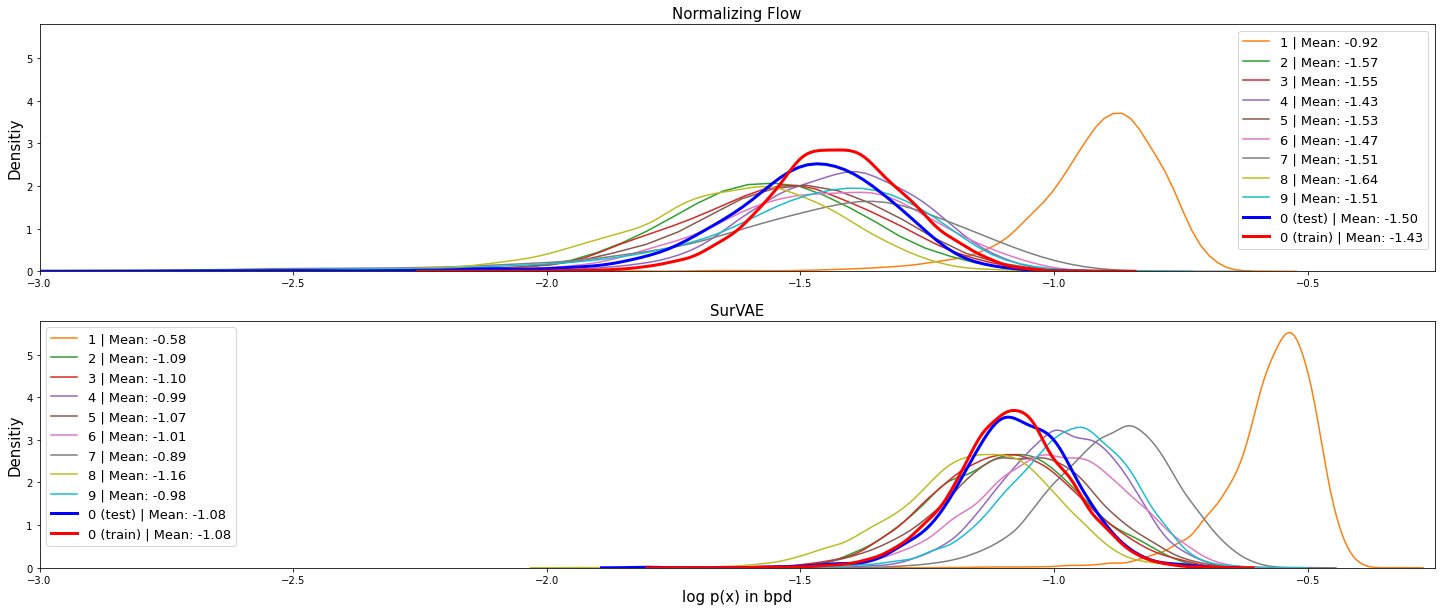

In [66]:
_=show_loss_histograms(all_losses, lim_left=-3, lim_right=-0.25)

--- 

# 4. Outlier Datapoints

In this section we look at real world samples from $D$ and plot the ones which obtain lowest and highest likelihoods.<br><br>
From a visual interpretation, we observe the same as Kirichenko [2], which is: the models seem to have learned a local pixel correlation. <br>
This means that an image with more structure (e.g. one with a '0') can more often fail to match the pixel correlation than one with a simple structure (e.g. a '1', which is often drawn as a pipe).
This leads to a lower likelihood.
The unmatched pixel correlation is especially visible in the pixelated borders of the number.<br>
Kirichenko [2] proposes methods to overcome this, but they are either not fully unsupervised or perform poorly.

[2] Kirichenko, Polina, Pavel Izmailov, and Andrew Gordon Wilson. "Why normalizing flows fail to detect out-of-distribution data." arXiv preprint arXiv:2006.08545 (2020).
<!--[3] Ren, Jie, et al. "Likelihood ratios for out-of-distribution detection." arXiv preprint arXiv:1906.02845 (2019).--> 

### 4.1.1 Images of $D_0^e$ with highest likelihood (descending)


Title = log p(x) in bpd


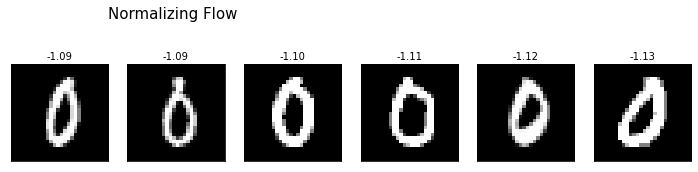

In [68]:
cols = 6
plot_best_or_worst_samples('nf', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=True, amount_per_class=cols, cols=cols, verbose=False)

(log p(x) in bpd, pixel mean, class)


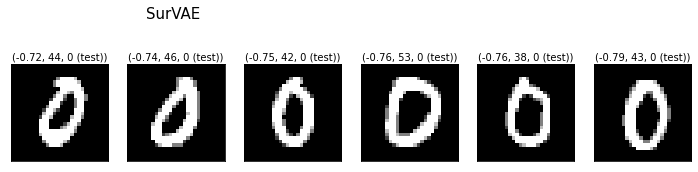

In [50]:
plot_best_or_worst_samples('survae', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=True, amount_per_class=cols, cols=cols, verbose=False)

### 4.1.2 Images of main class $D_0^e$ with lowest likelihood (ascending)

Title = log p(x) in bpd


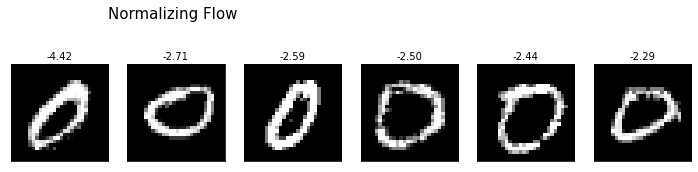

In [74]:
plot_best_or_worst_samples('nf', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, amount_per_class=cols, cols=cols, verbose=False)

Title = log p(x) in bpd


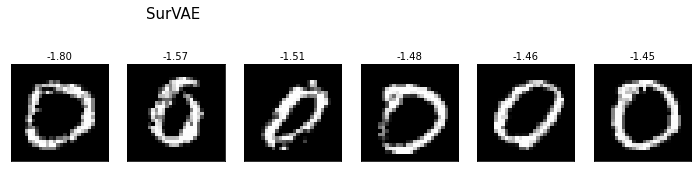

In [73]:
plot_best_or_worst_samples('survae', [MAIN_TEST_CLS], all_losses, all_loaders, best_images=False, amount_per_class=cols, cols=cols, verbose=False)

## Images with high likelihood from $D_1$

Title = log p(x) in bpd


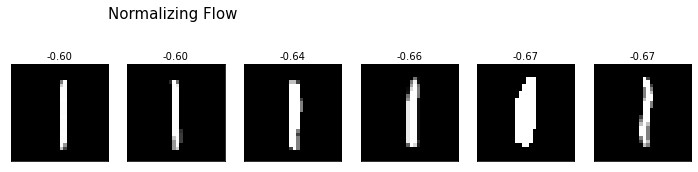

In [72]:
plot_best_or_worst_samples('nf', [1], all_losses, all_loaders, best_images=True, amount_per_class=cols, cols=cols, verbose=False)

Title = log p(x) in bpd


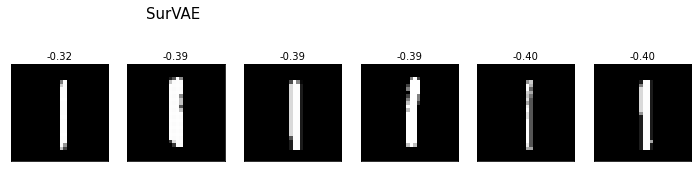

In [71]:
plot_best_or_worst_samples('survae', [1], all_losses, all_loaders, best_images=True, amount_per_class=cols, cols=cols, verbose=False)

## Images with low likelihood from $D_1$

Title = log p(x) in bpd


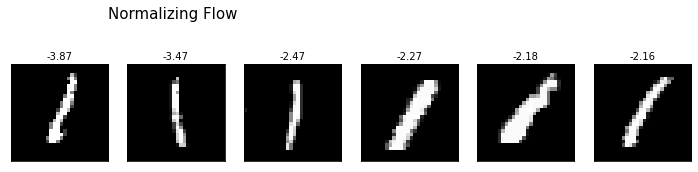

In [70]:
plot_best_or_worst_samples('nf', [1], all_losses, all_loaders, best_images=False, amount_per_class=cols, cols=cols, verbose=False)

Title = log p(x) in bpd


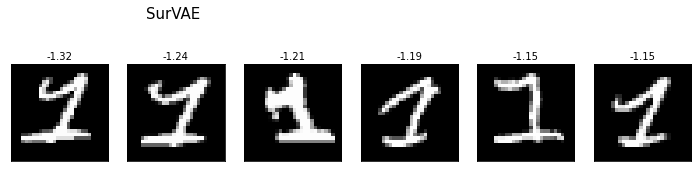

In [69]:
plot_best_or_worst_samples('survae', [1], all_losses, all_loaders, best_images=False, amount_per_class=cols, cols=cols, verbose=False)